In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/sample_submission.csv
/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/train.csv
/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split , GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import TargetEncoder, StandardScaler , OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [4]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

In [5]:
train_df = pd.read_csv('/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/train.csv')

In [6]:
test_df = pd.read_csv('/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/test.csv')

In [7]:
train_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,0,2023-06-28 17:31:46,2023-06-28 18:22:12,1.0,1.50,1.0,N,212,237,Credit Card,5.0,6.533210,0.0,1.0,24.80,2.5,0.0
1,0,2023-06-29 19:15:55,2023-06-29 19:07:31,1.0,3.80,1.0,N,6,163,Credit Card,5.0,9.187048,0.0,1.0,31.55,2.5,0.0
2,1,2023-06-30 18:28:50,2023-06-30 18:01:19,2.0,1.89,1.0,N,35,81,Credit Card,2.5,6.793777,0.0,1.0,24.84,2.5,0.0
3,1,2023-06-30 22:57:37,2023-06-30 22:55:34,1.0,1.10,1.0,N,46,99,Credit Card,1.0,3.695121,0.0,1.0,13.45,2.5,0.0
4,1,2023-06-28 18:39:16,2023-06-28 17:31:29,2.0,2.84,1.0,N,213,114,Credit Card,2.5,7.838753,0.0,1.0,29.88,2.5,0.0


In [8]:
train_df.shape

(10000, 17)

Criteria one for finding datatype for columns

In [9]:
columns = list(train_df.columns)
for i in range(len(columns)):
    print(i,columns[i],'---->',train_df[columns[i]].dtype)

0 VendorID ----> int64
1 tpep_pickup_datetime ----> object
2 tpep_dropoff_datetime ----> object
3 passenger_count ----> float64
4 trip_distance ----> float64
5 RatecodeID ----> float64
6 store_and_fwd_flag ----> object
7 PULocationID ----> int64
8 DOLocationID ----> int64
9 payment_type ----> object
10 extra ----> float64
11 tip_amount ----> float64
12 tolls_amount ----> float64
13 improvement_surcharge ----> float64
14 total_amount ----> float64
15 congestion_surcharge ----> float64
16 Airport_fee ----> float64


Criteria 2 --> Descriptive Statistics on numerical columns

In [10]:
train_df.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,10000.000000,9634.000000,10000.000000,9634.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9634.000000,9634.000000
mean,0.729100,1.357276,3.679527,1.450695,132.710800,132.33240,1.940950,6.094658,0.664425,0.979490,29.740157,2.238426,0.161122
std,0.444672,0.883676,4.905798,5.988978,75.789597,75.95944,1.945885,4.438894,2.441070,0.200076,26.256398,0.834189,0.512859
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,-7.500000,0.000713,-26.550000,-1.000000,-129.300000,-2.500000,-1.750000
25%,0.000000,1.000000,1.070000,1.000000,67.000000,68.00000,0.000000,3.466789,0.000000,1.000000,16.300000,2.500000,0.000000
50%,1.000000,1.000000,1.820000,1.000000,133.000000,132.00000,1.750000,5.208233,0.000000,1.000000,21.360000,2.500000,0.000000
75%,1.000000,1.000000,3.630000,1.000000,198.000000,199.00000,2.500000,7.455228,0.000000,1.000000,31.800000,2.500000,0.000000
max,2.000000,6.000000,71.940000,99.000000,264.000000,264.00000,11.750000,84.032617,32.050000,1.000000,551.000000,2.500000,1.750000


Criteria 3 --> Handling Missing Value(EDA)

In [11]:
train_df.isnull().sum()
#there are 366 out of 10000 missing values in column ['passenger_count','RatecodeID','store_and_fwd_flag','congestion_surcharge','Airport_fee']

VendorID                   0
tpep_pickup_datetime       0
tpep_dropoff_datetime      0
passenger_count          366
trip_distance              0
RatecodeID               366
store_and_fwd_flag       366
PULocationID               0
DOLocationID               0
payment_type               0
extra                      0
tip_amount                 0
tolls_amount               0
improvement_surcharge      0
total_amount               0
congestion_surcharge     366
Airport_fee              366
dtype: int64

Dropping unnecessary columns

In [12]:
columns_to_drop = ['store_and_fwd_flag', 'passenger_count', 'VendorID']

train_df = train_df.drop(columns=columns_to_drop)
test_df = test_df.drop(columns=columns_to_drop)

Preprocessing the features (forming new insights(features) from old features and drop old features)

In [13]:
def preprocess_features(df):
    df_eng = df.copy()
    
    # Convert string dates to datetime objects
    df_eng['tpep_pickup_datetime'] = pd.to_datetime(df_eng['tpep_pickup_datetime'])
    df_eng['tpep_dropoff_datetime'] = pd.to_datetime(df_eng['tpep_dropoff_datetime'])
    
    # Extract meaningful math from dates
    df_eng['duration_mins'] = (((df_eng['tpep_dropoff_datetime'] - df_eng['tpep_pickup_datetime']).dt.total_seconds() / 60.0))
    df_eng['pickup_hour'] = df_eng['tpep_pickup_datetime'].dt.hour
    df_eng['pickup_dayofweek'] = df_eng['tpep_pickup_datetime'].dt.dayofweek
    
    # Drop original datetime columns
    df_eng = df_eng.drop(columns=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])
    return df_eng

In [14]:
train_processed = preprocess_features(train_df)
test_processed = preprocess_features(test_df)
train_processed.shape

(10000, 15)

Identifying Duplicates and dropping if exist

In [15]:
duplicate_count = train_processed.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")
# There are no duplicated rows so there is nothing to drop 

Number of duplicate rows found: 0


Identifying Outliers 

In [16]:
train_processed.describe() 

,trip_distance,RatecodeID,PULocationID,DOLocationID,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,duration_mins,pickup_hour,pickup_dayofweek
count,10000.000000,9634.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9634.000000,9634.000000,10000.000000,10000.000000,10000.000000
mean,3.679527,1.450695,132.710800,132.33240,1.940950,6.094658,0.664425,0.979490,29.740157,2.238426,0.161122,17.094178,15.120400,3.201600
std,4.905798,5.988978,75.789597,75.95944,1.945885,4.438894,2.441070,0.200076,26.256398,0.834189,0.512859,58.760901,5.756407,0.744589
min,0.000000,1.000000,1.000000,1.00000,-7.500000,0.000713,-26.550000,-1.000000,-129.300000,-2.500000,-1.750000,-114.250000,0.000000,2.000000
25%,1.070000,1.000000,67.000000,68.00000,0.000000,3.466789,0.000000,1.000000,16.300000,2.500000,0.000000,-18.950000,12.000000,3.000000
50%,1.820000,1.000000,133.000000,132.00000,1.750000,5.208233,0.000000,1.000000,21.360000,2.500000,0.000000,15.833333,16.000000,3.000000
75%,3.630000,1.000000,198.000000,199.00000,2.500000,7.455228,0.000000,1.000000,31.800000,2.500000,0.000000,51.266667,19.000000,4.000000
max,71.940000,99.000000,264.000000,264.00000,11.750000,84.032617,32.050000,1.000000,551.000000,2.500000,1.750000,1483.583333,23.000000,5.000000


Visualizing ouliers (scatter_plot)

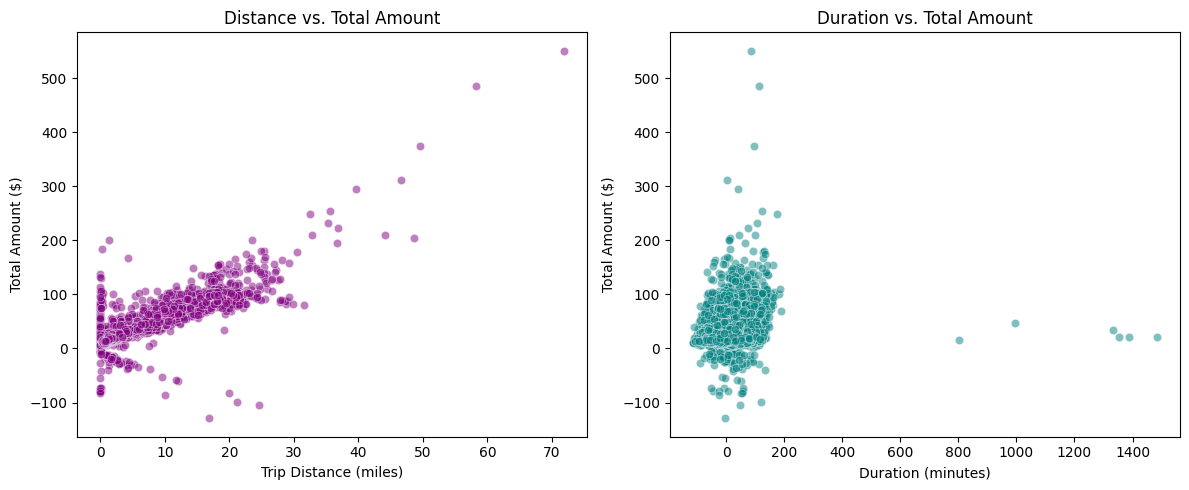

In [17]:
plt.figure(figsize=(12, 5))

# Seaborn Scatter 1: Distance vs Fare
plt.subplot(1, 2, 1)
sns.scatterplot(x='trip_distance', y='total_amount', data=train_processed, color='purple', alpha=0.5)
plt.title('Distance vs. Total Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Total Amount ($)')

# Seaborn Scatter 2: Duration vs Fare
plt.subplot(1, 2, 2)
sns.scatterplot(x='duration_mins', y='total_amount', data=train_processed, color='teal', alpha=0.5)
plt.title('Duration vs. Total Amount')
plt.xlabel('Duration (minutes)')
plt.ylabel('Total Amount ($)')

plt.tight_layout()
plt.show()

Handling Outliers

In [18]:
train_clean = train_processed[
    (train_processed['total_amount'] > 0) &                                        
    (train_processed['trip_distance'] > 0) &                                      
    ((train_processed['extra'] >= 0) | train_processed['extra'].isna()) &                  
    ((train_processed['tolls_amount'] >= 0) | train_processed['tolls_amount'].isna()) &    
    ((train_processed['Airport_fee'] >= 0) | train_processed['Airport_fee'].isna())        
]

outliers_removed = train_processed.shape[0] - train_clean.shape[0]
print('No. of outliers removed',outliers_removed)

No. of outliers removed 242


In [19]:
train_processed = train_clean
train_processed.shape  #we have removed ouliers which is needed

(9758, 15)

In [20]:
train_processed.describe()

,trip_distance,RatecodeID,PULocationID,DOLocationID,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,duration_mins,pickup_hour,pickup_dayofweek
count,9758.000000,9418.000000,9758.000000,9758.000000,9758.000000,9758.000000,9758.000000,9758.000000,9758.000000,9418.000000,9418.000000,9758.000000,9758.000000,9758.000000
mean,3.744558,1.385857,132.760607,132.338799,1.987497,6.164766,0.678489,0.999785,30.321651,2.298259,0.164446,17.278438,15.138758,3.200451
std,4.924511,5.530609,75.769103,75.875352,1.922394,4.440009,2.432711,0.012273,25.563896,0.680957,0.510652,58.954525,5.749994,0.745312
min,0.010000,1.000000,1.000000,1.000000,0.000000,0.000713,0.000000,0.300000,2.640000,0.000000,0.000000,-113.883333,0.000000,2.000000
25%,1.100000,1.000000,67.000000,68.000000,0.000000,3.540680,0.000000,1.000000,16.400000,2.500000,0.000000,-18.816667,12.000000,3.000000
50%,1.870000,1.000000,133.000000,132.000000,2.500000,5.284483,0.000000,1.000000,21.480000,2.500000,0.000000,16.025000,16.000000,3.000000
75%,3.700000,1.000000,199.000000,199.000000,2.500000,7.527560,0.000000,1.000000,31.900000,2.500000,0.000000,51.362500,19.000000,4.000000
max,71.940000,99.000000,264.000000,264.000000,11.750000,84.032617,32.050000,1.000000,551.000000,2.500000,1.750000,1483.583333,23.000000,5.000000


In [21]:
#but there are still NA(missing values in the dataset) 
train_processed.isna().sum()

trip_distance              0
RatecodeID               340
PULocationID               0
DOLocationID               0
payment_type               0
extra                      0
tip_amount                 0
tolls_amount               0
improvement_surcharge      0
total_amount               0
congestion_surcharge     340
Airport_fee              340
duration_mins              0
pickup_hour                0
pickup_dayofweek           0
dtype: int64

Pipeline for numerical and categorical data

In [22]:
# 1. Numerical Pipeline 
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

In [23]:
# 2. Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('target_enc', TargetEncoder(target_type='continuous', smooth="auto"))
])

In [24]:
# 3.
categorical_cols = ['RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type']
numeric_cols = ['trip_distance', 'duration_mins', 'pickup_hour', 'pickup_dayofweek']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


In [25]:
features_to_use = [
    'trip_distance', 'duration_mins', 'pickup_hour', 'pickup_dayofweek', 
    'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type'
]


X = train_processed[features_to_use] #feature matrix
y = train_processed['total_amount'] #target variable

# Save test IDs for the final submission and drop from test features
test_ids = test_processed['id']
X_test_final = test_processed.drop(columns=['id'])

In [26]:
# Create Validation Set (80% Train, 20% Validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
print(train_processed.shape[0]-X_train.shape[0])
print(X_val.shape[0])

1952
1952


Models

In [28]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42),
    'Gradient Boosting':GradientBoostingRegressor(
    n_estimators=500,           
    learning_rate=0.05,         
    max_depth=4,               
    min_samples_leaf=50,       
    n_iter_no_change=15,        
    validation_fraction=0.1,    
    random_state=42
),
    'KNN Regression': KNeighborsRegressor(n_neighbors=5)
}

In [29]:
if 'total_amount' in numeric_cols:
    numeric_cols.remove('total_amount')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [30]:
baseline_results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    
    r2 = r2_score(y_val, y_pred)
    baseline_results[name] = r2
    print(f"{name:<20} -> Validation R2 Score: {r2:.2f}")

Linear Regression    -> Validation R2 Score: 0.90
Ridge Regression     -> Validation R2 Score: 0.90
Lasso Regression     -> Validation R2 Score: 0.90
Decision Tree        -> Validation R2 Score: 0.87
Random Forest        -> Validation R2 Score: 0.93
Gradient Boosting    -> Validation R2 Score: 0.92
KNN Regression       -> Validation R2 Score: 0.77


Hyper Parameter Tuning for Ridge,Lasso,Random Forest

In [31]:
# 1. Tuning Ridge Regression (Correct)
print("Tuning Ridge Regression...")
ridge_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge())])
ridge_params = {'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]}
ridge_search = GridSearchCV(ridge_pipe, ridge_params, cv=5, scoring='r2')
ridge_search.fit(X_train, y_train) 
print(f"Best Ridge Alpha: {ridge_search.best_params_['regressor__alpha']}")
print(f"Tuned Ridge Validation R2: {r2_score(y_val, ridge_search.predict(X_val)):.2f}\n")


# 2. Tuning Lasso Regression (Correct)
print("Tuning Lasso Regression...")
lasso_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Lasso(max_iter=2000))])
lasso_params = {'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
lasso_search = GridSearchCV(lasso_pipe, lasso_params, cv=5, scoring='r2')
lasso_search.fit(X_train, y_train)
print(f"Best Lasso Alpha: {lasso_search.best_params_['regressor__alpha']}")
print(f"Tuned Lasso Validation R2: {r2_score(y_val, lasso_search.predict(X_val)):.2f}\n")


# 3. Tuning Random Forest (Corrected Naming)
print("Tuning Random Forest...")
rf_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))])

param_dist = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [10, 15, 20, None],
    'regressor__min_samples_leaf': [5, 10, 20],
    'regressor__max_features': [1.0, 'sqrt', 'log2'] 
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe, 
    param_distributions=param_dist,
    n_iter=10, 
    cv=3, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=2,
    random_state=42
)

rf_search.fit(X_train, y_train)
best_rf_model = rf_search.best_estimator_

print(f"Best Parameters Found: {rf_search.best_params_}")
print(f"Best Cross-Validation R2: {rf_search.best_score_:.2f}")

Tuning Ridge Regression...
Best Ridge Alpha: 100.0
Tuned Ridge Validation R2: 0.90

Tuning Lasso Regression...
Best Lasso Alpha: 0.01
Tuned Lasso Validation R2: 0.90

Tuning Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters Found: {'regressor__n_estimators': 300, 'regressor__min_samples_leaf': 5, 'regressor__max_features': 1.0, 'regressor__max_depth': None}
Best Cross-Validation R2: 0.90


In [32]:
final_predictions = best_rf_model.predict(X_test_final)
submission = pd.DataFrame({'id': test_ids, 'total_amount': final_predictions})
submission.to_csv('submission.csv', index=False)